Importing necessary libraries


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression, Lasso, Ridge
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, confusion_matrix
from matplotlib.colors import to_rgb
from tabulate import tabulate
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import plot_tree

# **Data preperation**

## Dataset Description
The dataset used in this project is the Breast Cancer Wisconsin dataset. It contains 569 samples, each with 30 numerical features describing characteristics of the cell nuclei present in images. The target variable, `diagnosis`, classifies the tumor as either Benign (B) or Malignant (M). This dataset is widely used for predictive modeling in healthcare and machine learning research.

### Key Features:
- `radius_mean`, `texture_mean`: Measures of tumor size and appearance.
- `concavity_mean`, `smoothness_mean`: Describe tumor shape.
- `perimeter_mean`, `area_mean`: Represent the tumor's geometrical features.


## Class Distribution

The dataset contains **357 Benign** and **212 Malignant** samples, resulting in a slight class imbalance. This imbalance could lead to biased predictions, emphasizing the need for evaluation metrics beyond accuracy, such as precision and recall.

## reference to the dataset source

This dataset was obtained from the [UCI Machine Learning Repository] [https://github.com/pkmklong/Breast-Cancer-Wisconsin-Diagnostic-DataSet/blob/master/data.csv].

Loading the dataset

In [3]:
data = pd.read_csv('data.csv')

Check for null values

In [4]:
print("Null values per column:")
print(data.isnull().sum())


Null values per column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimensi

-Droping unnecessary column

-Fill the Null the values (even there is none , but we did it so we do not deal with null values if they exist later on)


In [5]:
#dropping the column unnamed
if 'Unnamed: 32' in data.columns:
    data.drop(columns=['Unnamed: 32'], inplace=True)

#dropping the column id
if 'id' in data.columns:
    data.drop(columns=['id'], inplace=True)

# For numerical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].mean(), inplace=True)

# For categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].mode()[0], inplace=True)

# Confirm no null values remain
print("\nNull values after filling:")
print(data.isnull().sum())




Null values after filling:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


# **EXPLORATORY DATA ANALYSIS (EDA)**

In [6]:
# View the first few rows as a sample.
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Information about the data

In [7]:
print("Basic Information:")
print(data.info())

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se

-statistical summary

In [8]:
print(data.describe())

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

Distribution of Target Variable

In [9]:
target_column = 'diagnosis'  # Change this to the correct column
if target_column in data.columns:
    print(f"\nDistribution of {target_column}:")
    print(data[target_column].value_counts())


Distribution of diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


Converting diagnosis ("M" and "B") into numerical format using Label Encoding

In [10]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

Correations with features

In [11]:
# Check for correlations with the target
correlations = data.corr()['diagnosis'].sort_values(ascending=False)
print("\nCorrelation with the target (diagnosis):\n", correlations)



Correlation with the target (diagnosis):
 diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se 

Visualize the top correlated features with diagnosis

<ipython-input-12-8a6a9791d65d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features], y=top_features, palette='coolwarm')


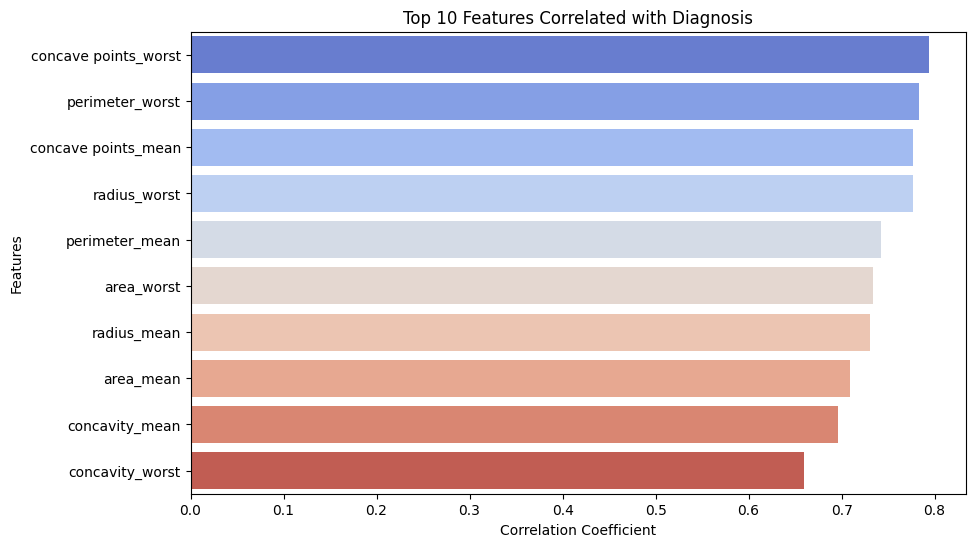

In [12]:
top_features = correlations[1:11].index  # Select top 10 features excluding target itself
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations[top_features], y=top_features, palette='coolwarm')
plt.title('Top 10 Features Correlated with Diagnosis')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

 Heatmap to show overall feature correlatio

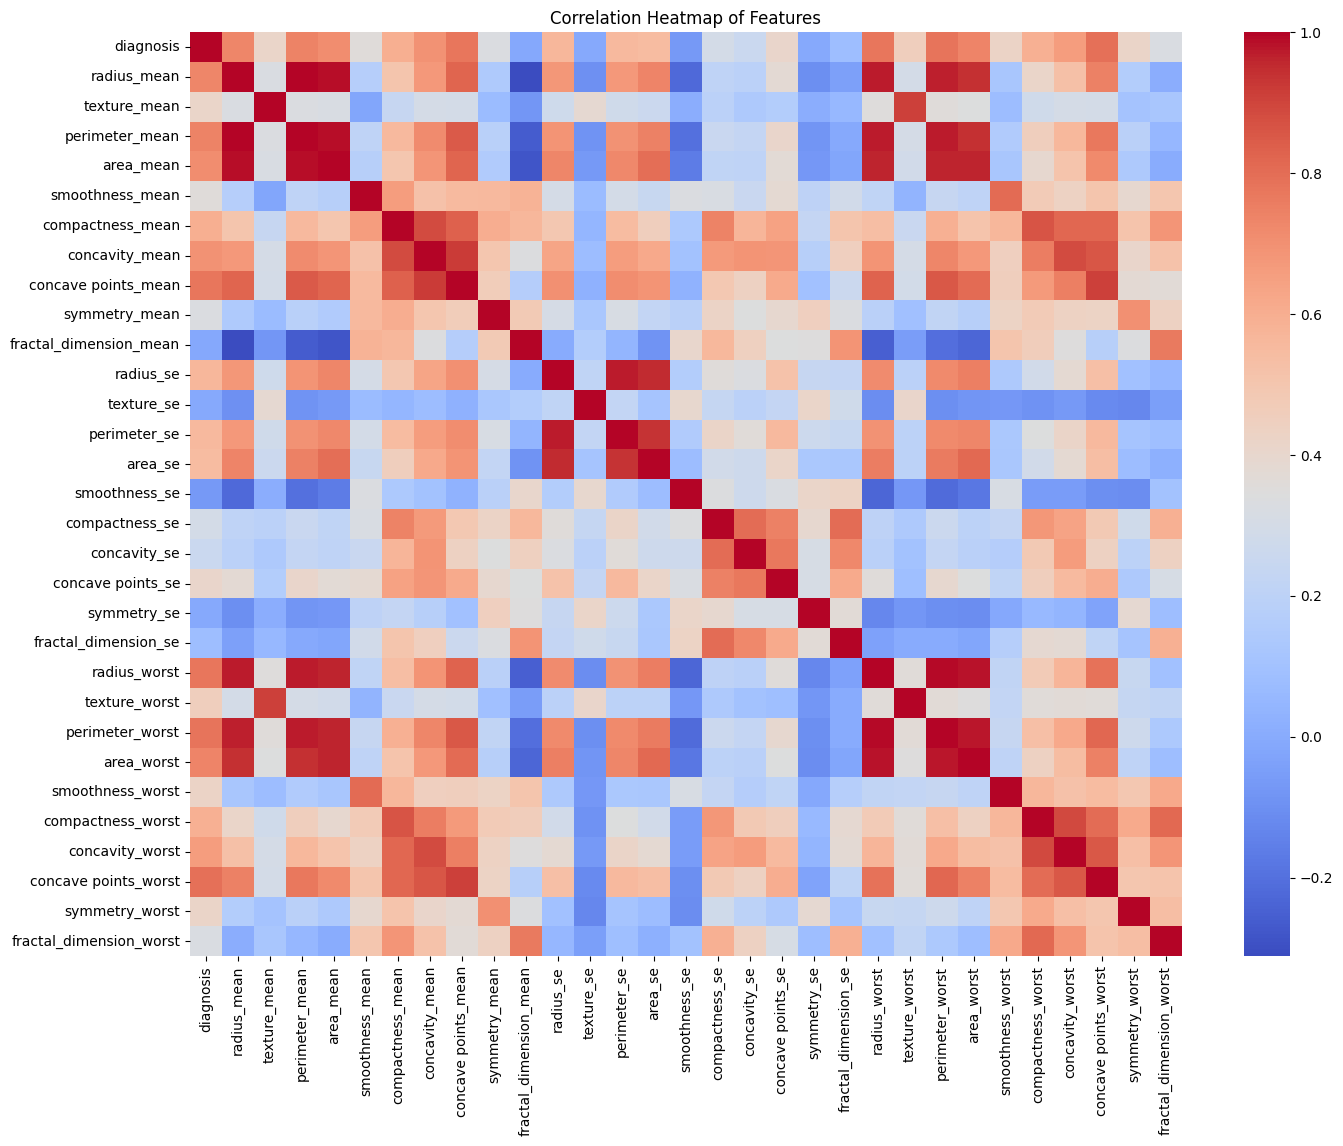

In [13]:
plt.figure(figsize=(16, 12))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Features')
plt.show()

# **DATA PREPROCESSING**

Selecting relevant features for modeling

In [14]:
X = data[top_features]
y = data['diagnosis']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling (Standardization) - Normalize numerical features

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **DATA REGURALIZATION**

### Why Regularization?
- **L1 (Lasso):** Encourages sparsity by shrinking some coefficients to zero, effectively performing feature selection.
- **L2 (Ridge):** Penalizes large coefficients, reducing the risk of overfitting. This is particularly useful for high-dimensional data.

### Feature Engineering
PCA was applied to reduce the dimensionality of the data while retaining maximum variance. This helps improve model performance and reduces noise.

Applying L1 Requralization

In [16]:
# Lasso Regularization (L1)
lasso_model = LogisticRegression(penalty='l1', solver='saga', max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=10000, penalty='l1', solver='saga')

Applying l2 Reguralization

In [17]:
# Ridge Regularization (L2)
ridge_model = LogisticRegression(penalty='l2', solver='saga', max_iter=10000)
ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, solver='saga')

# **MODEL SELECTION**


##We evaluated the following models:
- **Lasso and Ridge (Linear Models):** Ideal for identifying linear relationships and feature importance.
- **KNN:** A simple algorithm that considers similarity between samples, suitable for small datasets.
- **SVC:** Works well with high-dimensional data and is robust to overfitting.
- **Random Forest:** A tree-based ensemble method, effective for capturing non-linear relationships.

Evaluating L1

In [18]:
# Predicting with Lasso Model
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Accuracy and other metrics for Lasso Model
print(f"Accuracy of Lasso (L1) model: {accuracy_score(y_test, y_pred_lasso):.4f}")
print("Classification Report for Lasso (L1):")
print(classification_report(y_test, y_pred_lasso))

Accuracy of Lasso (L1) model: 0.9737
Classification Report for Lasso (L1):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix for Lasso (l1)

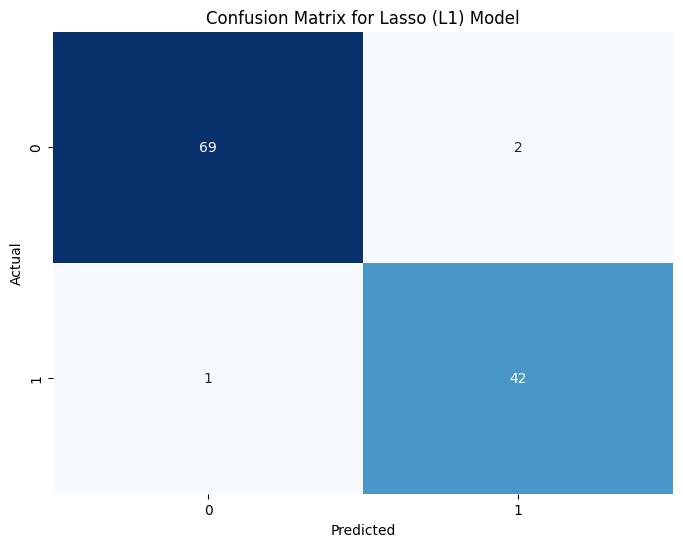

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lasso), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Lasso (L1) Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Evaluating L2

In [20]:
# Ridge Regularization (L2)
ridge_model = LogisticRegression(penalty='l2', solver='saga', max_iter=10000)
ridge_model.fit(X_train_scaled, y_train)

# Predicting with Ridge Model
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Accuracy and other metrics for Ridge Model
print(f"Accuracy of Ridge (L2) model: {accuracy_score(y_test, y_pred_ridge):.4f}")
print("Classification Report for Ridge (L2):")
print(classification_report(y_test, y_pred_ridge))

Accuracy of Ridge (L2) model: 0.9737
Classification Report for Ridge (L2):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix for Ridge (l2)

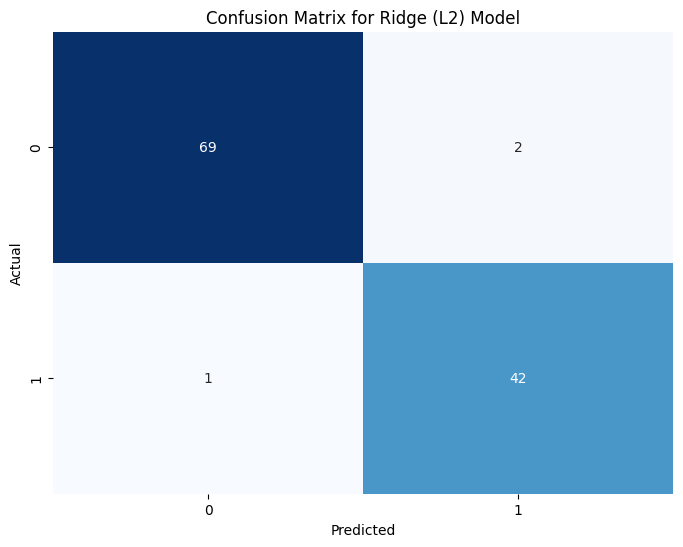

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ridge), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Ridge (L2) Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Comparing l1 and l2

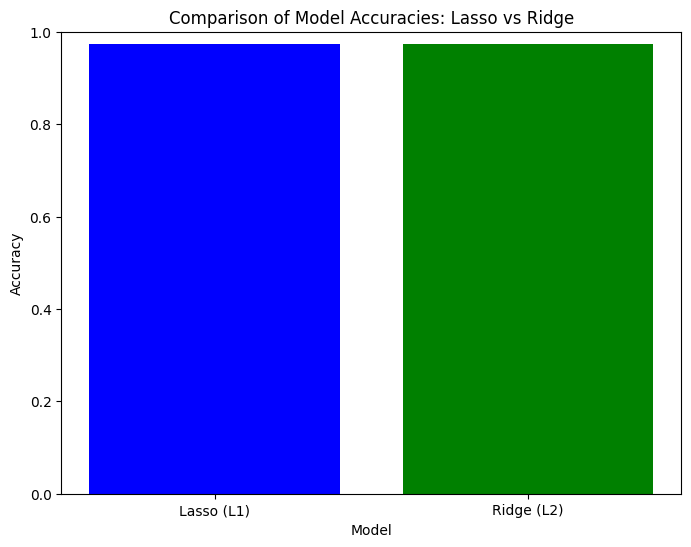

In [22]:
# Compare Accuracy of L1 and L2 models
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)

# Plotting a bar chart to compare accuracies
plt.figure(figsize=(8, 6))
models = ['Lasso (L1)', 'Ridge (L2)']
accuracies = [accuracy_lasso, accuracy_ridge]
plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies: Lasso vs Ridge')
plt.ylim(0, 1)
plt.show()

## **2. KNN Classifier**

In [23]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn_classifier.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"K-Nearest Neighbors Accuracy: {knn_accuracy:.4f}")


K-Nearest Neighbors Accuracy: 0.9737


Additional Metrics

In [24]:
print("Classification Report (Precision, Recall, F1-score):")
print(classification_report(y_test, knn_pred))

Classification Report (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix

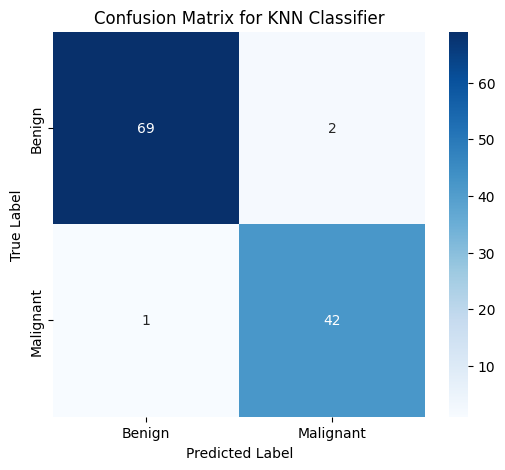

In [25]:
cm = confusion_matrix(y_test, knn_pred)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix for KNN Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

ROC Curve

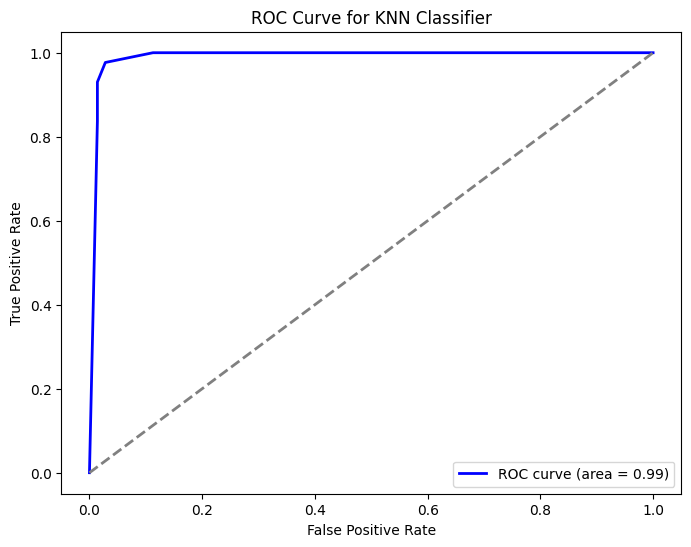

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, knn_classifier.predict_proba(X_test_scaled)[:, 1])
roc_auc = roc_auc_score(y_test, knn_classifier.predict_proba(X_test_scaled)[:, 1])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN Classifier')
plt.legend(loc="lower right")
plt.show()

Precision-Recall curve

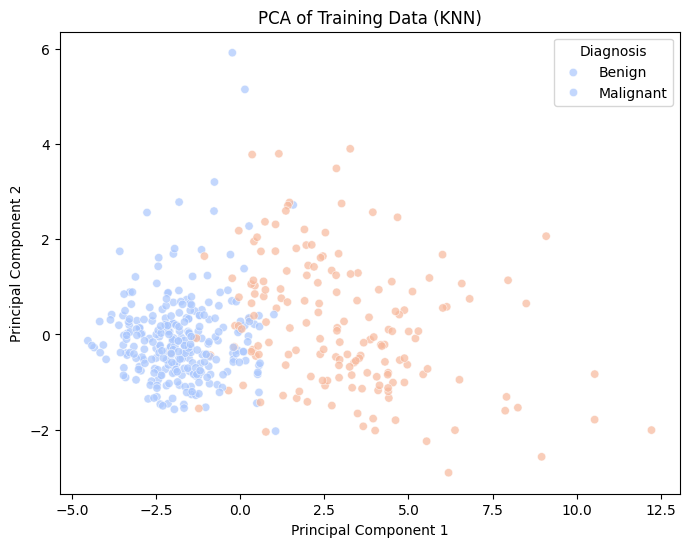

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Scatter plot of the PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='coolwarm', alpha=0.7)
plt.title('PCA of Training Data (KNN)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis', labels=['Benign', 'Malignant'])
plt.show()

## **3. SVC Classifier**

In [28]:
# Initialize SVC with a linear kernel (you can change the kernel if needed)
svc_model = SVC(kernel='linear', random_state=42)

# Fit the model on the scaled training data
svc_model.fit(X_train_scaled, y_train)

# Predict using the trained model
y_pred_svc = svc_model.predict(X_test_scaled)

# Calculate accuracy and precision
accuracy = accuracy_score(y_test, y_pred_svc)
precision = precision_score(y_test, y_pred_svc)

# Print accuracy and precision
print(f"Accuracy of SVC model: {accuracy:.4f}")
print(f"Precision of SVC model: {precision:.4f}")

Accuracy of SVC model: 0.9825
Precision of SVC model: 0.9767


Confusion Matrix

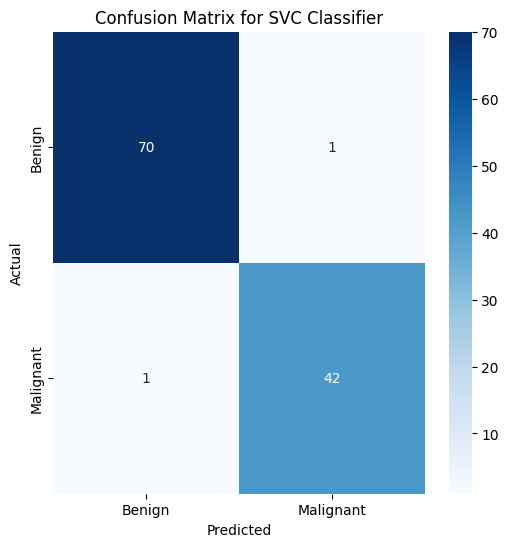

In [29]:
cm = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix for SVC Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Classification Report

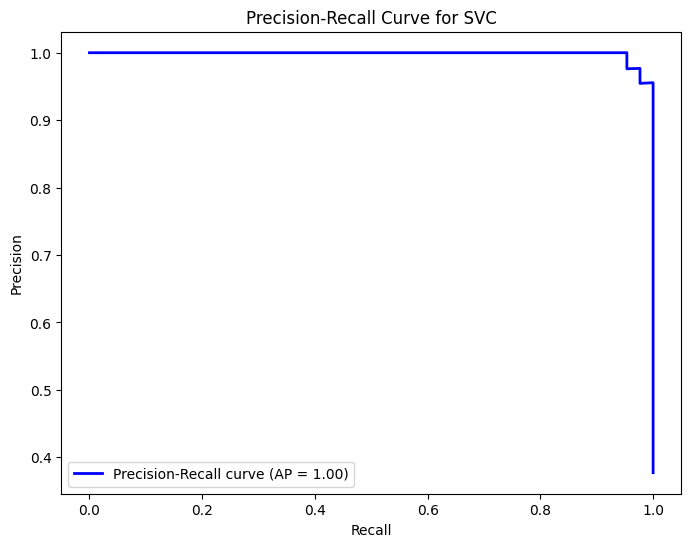

In [30]:
# Get precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, svc_model.decision_function(X_test_scaled))

# Compute Average Precision
average_precision = average_precision_score(y_test, svc_model.decision_function(X_test_scaled))

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.title('Precision-Recall Curve for SVC')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

ROC curve

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, svc_model.decision_function(X_test_scaled))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Learning Curve

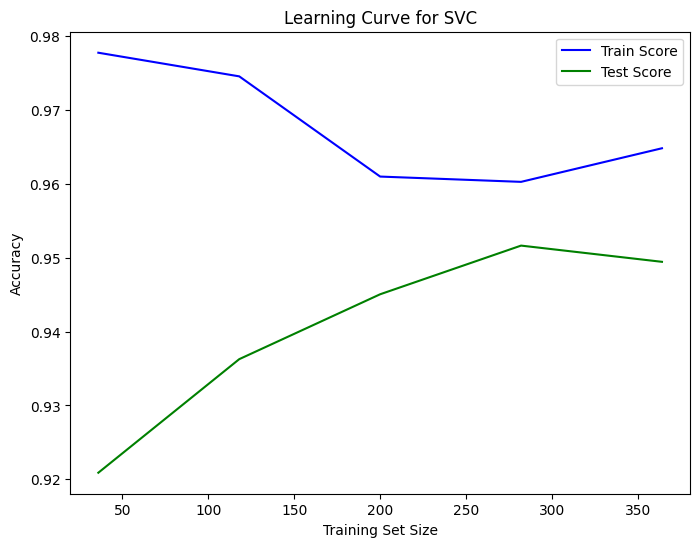

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(svc_model, X_train_scaled, y_train, cv=5)

# Plot learning curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Score', color='blue')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test Score', color='green')
plt.title('Learning Curve for SVC')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## **4. Random Forest Classifier**

In [32]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

Accuracy: 0.9561
Precision: 0.9524
Recall: 0.9302
F1 Score: 0.9412


Confusion Matrix

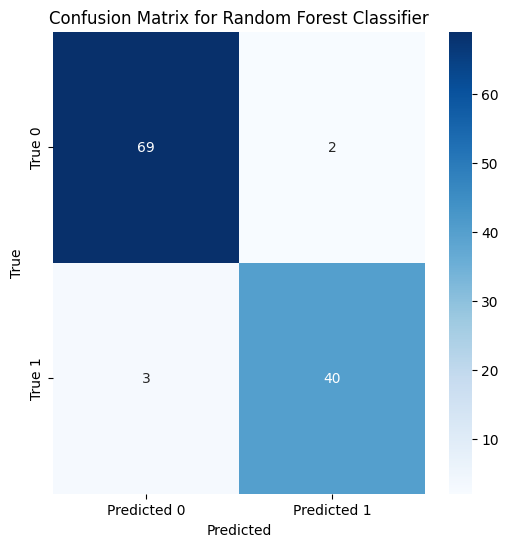

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1']
)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

ROC Curve

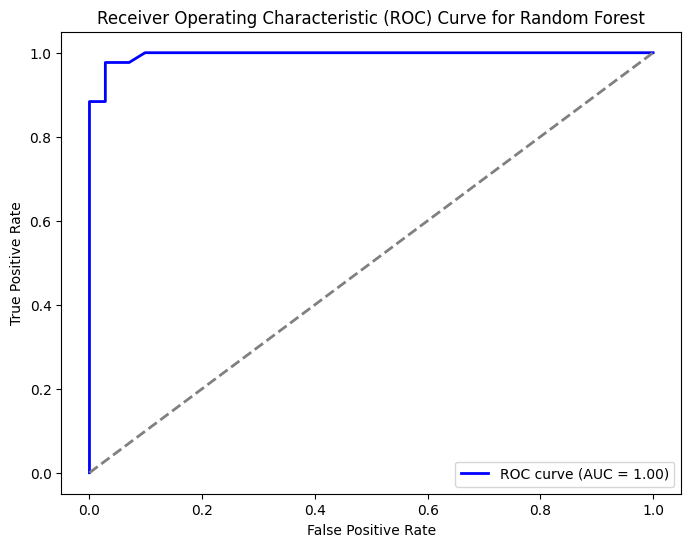

In [34]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Feature importance from the modal Forest Model

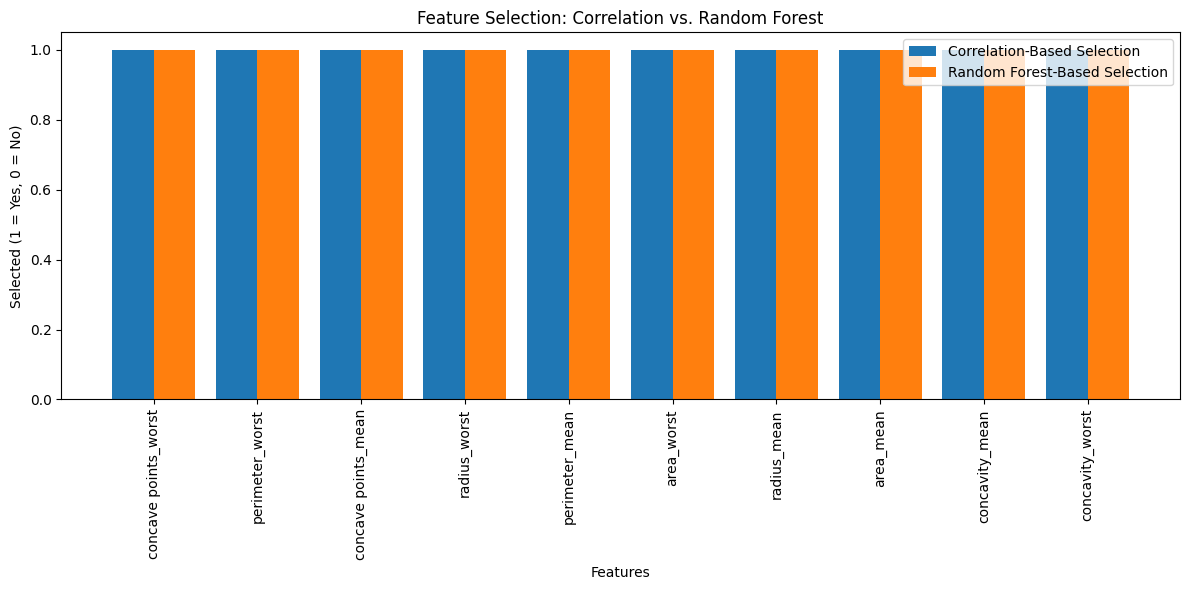

Overlapping Features (10): ['perimeter_mean', 'area_mean', 'concave points_mean', 'area_worst', 'radius_worst', 'perimeter_worst', 'radius_mean', 'concavity_worst', 'concave points_worst', 'concavity_mean']


In [ ]:
all_features = X.columns
correlation_selected = [1 if feature in top_features_names else 0 for feature in all_features]
rf_selected = [1 if feature in top_features_rf_names else 0 for feature in all_features]

plt.figure(figsize=(12, 6))
bar_width = 0.4
x_indices = np.arange(len(all_features))

plt.bar(x_indices - bar_width / 2, correlation_selected, bar_width, label='Correlation-Based Selection')
plt.bar(x_indices + bar_width / 2, rf_selected, bar_width, label='Random Forest-Based Selection')

plt.xlabel('Features')
plt.ylabel('Selected (1 = Yes, 0 = No)')
plt.title('Feature Selection: Correlation vs. Random Forest')
plt.xticks(ticks=x_indices, labels=all_features, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Overlapping Features
overlap_features = list(set(top_features_names).intersection(top_features_rf_names))
print(f"Overlapping Features ({len(overlap_features)}): {overlap_features}")


Precision-Recall Curve

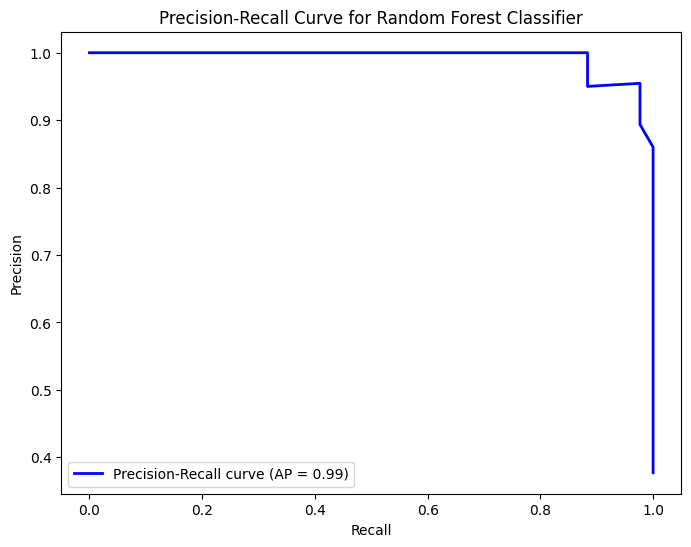

In [ ]:
precision_pr, recall_pr, _ = precision_recall_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
average_precision_rf = average_precision_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall_pr, precision_pr, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision_rf:.2f})')
plt.title('Precision-Recall Curve for Random Forest Classifier')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

first decision tree in the Random Forest

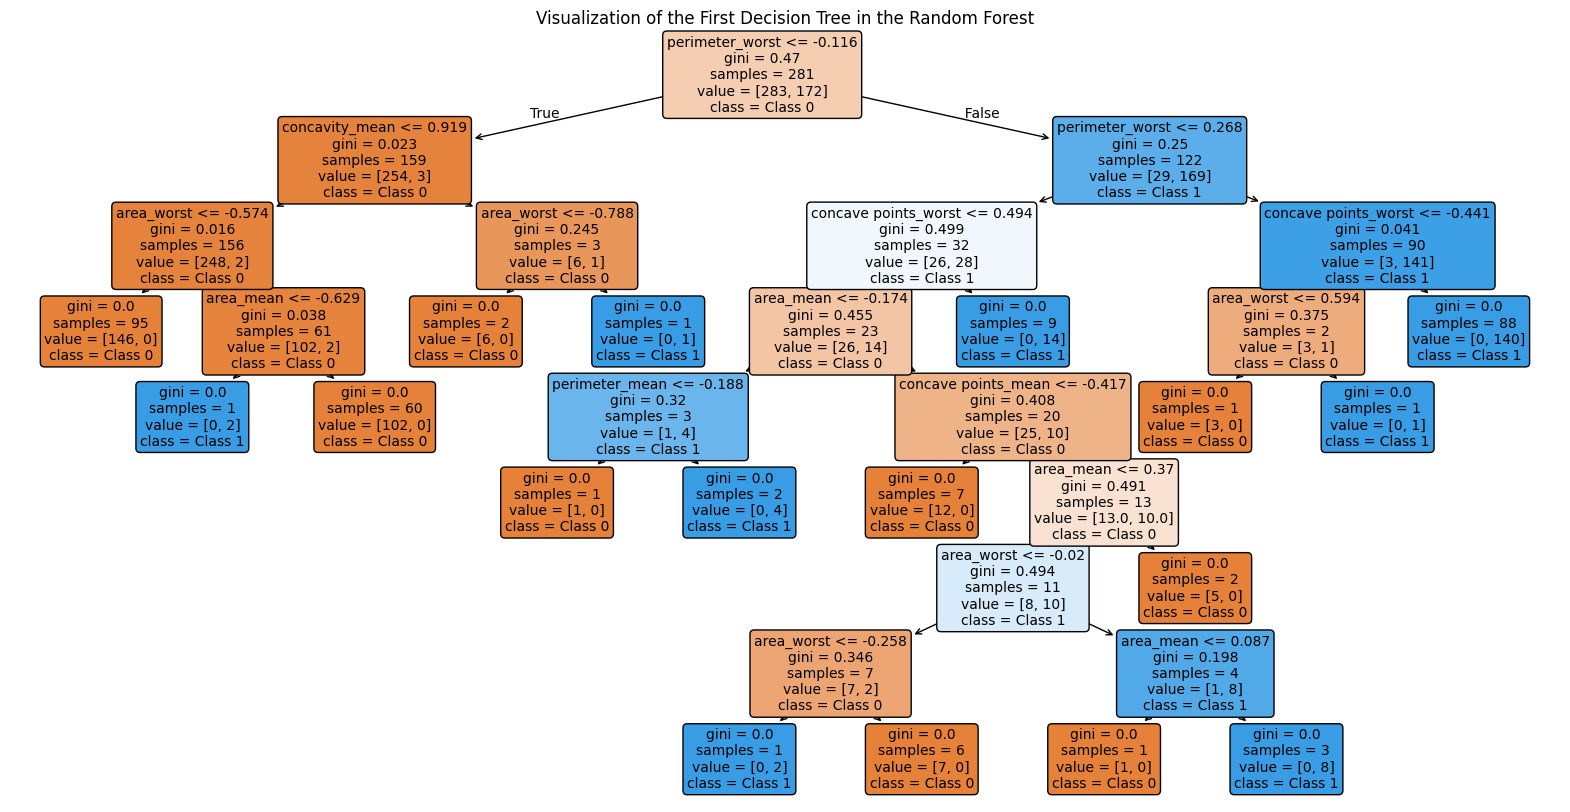

In [ ]:
first_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=X.columns,
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualization of the First Decision Tree in the Random Forest")
plt.show()

# ***Comparaison Between Models***

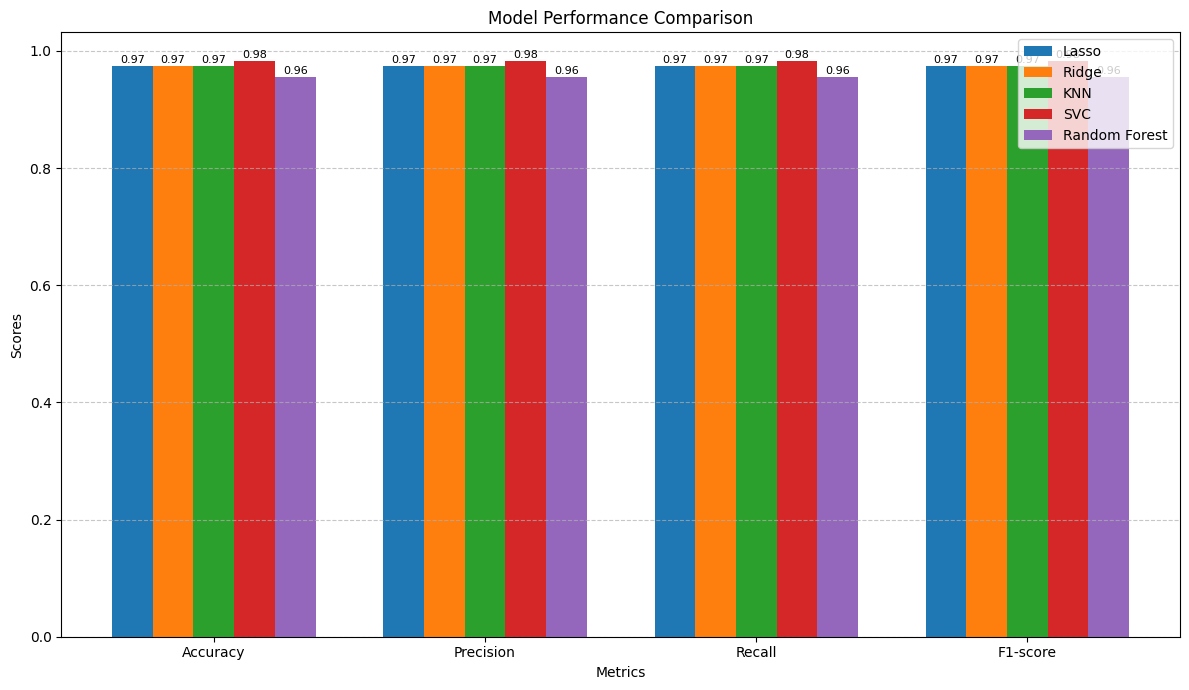

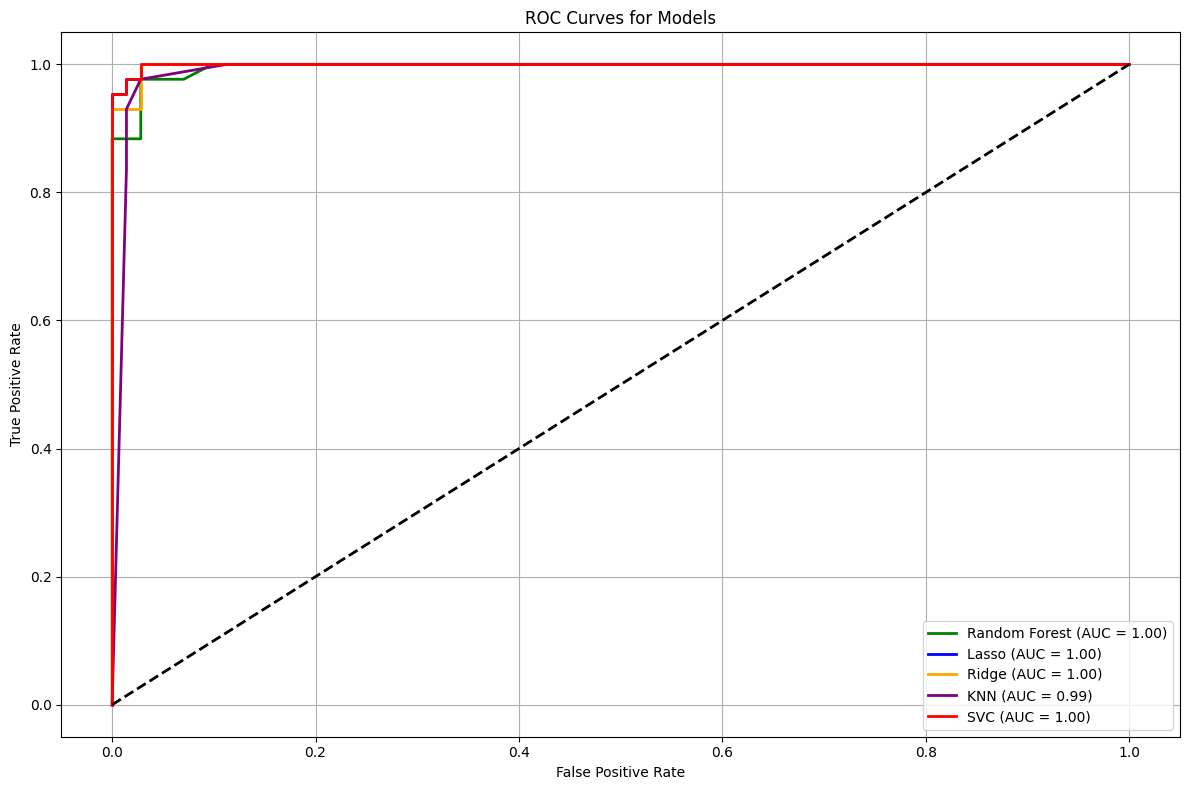

In [ ]:
# Metrics for all models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Initialize metric storage
model_names = ['Lasso', 'Ridge', 'KNN', 'SVC', 'Random Forest']
metric_values = []

# Lasso Model
precision_lasso, recall_lasso, f1_score_lasso, _ = precision_recall_fscore_support(y_test, y_pred_lasso, average='weighted')
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
metric_values.append([accuracy_lasso, precision_lasso, recall_lasso, f1_score_lasso])

# Ridge Model
precision_ridge, recall_ridge, f1_score_ridge, _ = precision_recall_fscore_support(y_test, y_pred_ridge, average='weighted')
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
metric_values.append([accuracy_ridge, precision_ridge, recall_ridge, f1_score_ridge])

# KNN Model
precision_knn, recall_knn, f1_score_knn, _ = precision_recall_fscore_support(y_test, knn_pred, average='weighted')
accuracy_knn = accuracy_score(y_test, knn_pred)
metric_values.append([accuracy_knn, precision_knn, recall_knn, f1_score_knn])

# SVC Model
precision_svc, recall_svc, f1_score_svc, _ = precision_recall_fscore_support(y_test, y_pred_svc, average='weighted')
accuracy_svc = accuracy_score(y_test, y_pred_svc)
metric_values.append([accuracy_svc, precision_svc, recall_svc, f1_score_svc])

# Random Forest Model
precision_rf, recall_rf, f1_score_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')
accuracy_rf = accuracy_score(y_test, y_pred_rf)
metric_values.append([accuracy_rf, precision_rf, recall_rf, f1_score_rf])

# Convert metric_values to a numpy array for easier manipulation
metric_values = np.array(metric_values)

# Bar Plot
plt.figure(figsize=(12, 7))
bar_width = 0.15
index = np.arange(len(metrics))

for i, model_name in enumerate(model_names):
    plt.bar(index + i * bar_width, metric_values[i], bar_width, label=model_name)

# Annotate bars
for i in range(len(model_names)):
    for j in range(len(metrics)):
        plt.text(index[j] + i * bar_width, metric_values[i][j] + 0.005, f'{metric_values[i][j]:.2f}', ha='center', fontsize=8)

plt.xticks(index + bar_width * (len(model_names) / 2 - 0.5), metrics)
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(12, 8))

# Probabilities for ROC (if available)
# Assuming `lasso_model`, `ridge_model`, `knn_classifier`, `svc_model`, `rf_model` support probability prediction
prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', lw=2, color='green')

if hasattr(lasso_model, "predict_proba"):
    prob_lasso = lasso_model.predict_proba(X_test_scaled)[:, 1]
    fpr_lasso, tpr_lasso, _ = roc_curve(y_test, prob_lasso)
    roc_auc_lasso = auc(fpr_lasso, tpr_lasso)
    plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso (AUC = {roc_auc_lasso:.2f})', lw=2, color='blue')

if hasattr(ridge_model, "predict_proba"):
    prob_ridge = ridge_model.predict_proba(X_test_scaled)[:, 1]
    fpr_ridge, tpr_ridge, _ = roc_curve(y_test, prob_ridge)
    roc_auc_ridge = auc(fpr_ridge, tpr_ridge)
    plt.plot(fpr_ridge, tpr_ridge, label=f'Ridge (AUC = {roc_auc_ridge:.2f})', lw=2, color='orange')

if hasattr(knn_classifier, "predict_proba"):
    prob_knn = knn_classifier.predict_proba(X_test_scaled)[:, 1]
    fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
    roc_auc_knn = auc(fpr_knn, tpr_knn)
    plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.2f})', lw=2, color='purple')

if hasattr(svc_model, "decision_function"):
    prob_svc = svc_model.decision_function(X_test_scaled)
    fpr_svc, tpr_svc, _ = roc_curve(y_test, prob_svc)
    roc_auc_svc = auc(fpr_svc, tpr_svc)
    plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_svc:.2f})', lw=2, color='red')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

Displaying all the Data in the table

In [ ]:
# Collect all metrics into a dictionary for easy DataFrame creation
results = pd.DataFrame({
    "Model": ["Lasso (L1)", "Ridge (L2)", "KNN", "SVC", "Random Forest"],
    "Accuracy": [accuracy_lasso, accuracy_ridge, accuracy_knn, accuracy_svc, accuracy_rf],
    "Precision": [precision_lasso, precision_ridge, precision_knn, precision_svc, precision_rf],
    "Recall": [recall_lasso, recall_ridge, recall_knn, recall_svc, recall_rf],
    "F1-Score": [f1_score_lasso, f1_score_ridge, f1_score_knn, f1_score_svc, f1_score_rf]
})


results


,Model,Accuracy,Precision,Recall,F1-Score
0,Lasso (L1),0.973684,0.973958,0.973684,0.973742
1,Ridge (L2),0.973684,0.973958,0.973684,0.973742
2,KNN,0.973684,0.973958,0.973684,0.973742
3,SVC,0.982456,0.982456,0.982456,0.982456
4,Random Forest,0.956140,0.956088,0.956140,0.956036


# **Conlusion:**


SVC (Support Vector Classifier) emerged as the best performing model, achieving the highest scores across all metrics:

    Accuracy: 98.24%
    Precision: 98.25%
    Recall: 98.25%
    F1-Score: 98.25%

This suggests that the SVC model is the most reliable and balanced in its ability to correctly classify the target variable, while also avoiding false positives and capturing the majority of relevant data.

Lasso (L1), Ridge (L2), and KNN models showed very similar performance, all achieving scores of around 97.37%. While they did not outperform SVC, they still provided strong results, demonstrating their robustness and reliability for the given problem.

Random Forest, although still a strong model, was slightly behind in performance with Accuracy at 95.61%. However, it still performed well with Precision, Recall, and F1-Score close to 95%, indicating that it could still be useful for certain applications where interpretability or feature importance analysis is more important.

# **Hyperparameter Tuning**


1-lasso

In [35]:
lasso = Lasso()
lasso_param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_search = GridSearchCV(lasso, lasso_param_grid, scoring='r2', cv=5)
lasso_search.fit(X_train, y_train)
lasso_best_params = lasso_search.best_params_
lasso_best_score = lasso_search.best_score_

print("Lasso Best Params:", lasso_best_params, "Best Score:", lasso_best_score)

Lasso Best Params: {'alpha': 0.01} Best Score: 0.6414354777949198


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.090e+01, tolerance: 8.638e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.110e+01, tolerance: 8.440e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.613e-03, tolerance: 8.269e

2-ridge

In [37]:
ridge = Ridge()
ridge_param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_search = GridSearchCV(ridge, ridge_param_grid, scoring='r2', cv=5)
ridge_search.fit(X_train, y_train)
ridge_best_params = ridge_search.best_params_
ridge_best_score = ridge_search.best_score_

print("Ridge Best Params:", ridge_best_params, "Best Score:", ridge_best_score)

Ridge Best Params: {'alpha': 0.01} Best Score: 0.7024463608553083


3-KNN

In [39]:
knn = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_search = GridSearchCV(knn, knn_param_grid, scoring='accuracy', cv=5)
knn_search.fit(X_train, y_train)
knn_best_params = knn_search.best_params_
knn_best_score = knn_search.best_score_

print("KNN Best Params:", knn_best_params, "Best Score:", knn_best_score)

KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} Best Score: 0.9318681318681319


4-SVC

In [41]:
svc = SVC()
svc_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}
svc_search = GridSearchCV(svc, svc_param_grid, scoring='accuracy', cv=5)
svc_search.fit(X_train, y_train)
svc_best_params = svc_search.best_params_
svc_best_score = svc_search.best_score_

print("SVC Best Params:", svc_best_params, "Best Score:", svc_best_score)

SVC Best Params: {'C': 10, 'gamma': 1, 'kernel': 'linear'} Best Score: 0.9362637362637363


5-Random forest

In [91]:
random_forest = RandomForestClassifier()
rf_param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizedSearchCV with reduced verbosity
rf_search = RandomizedSearchCV(
    random_forest,
    rf_param_distributions,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    verbose=0,  # Suppress detailed output
    random_state=42
)

# Fit the model
rf_search.fit(X_train, y_train)

# Get best parameters and score
rf_best_params = rf_search.best_params_
rf_best_score = rf_search.best_score_

print("Random Forest Best Params:", rf_best_params, "Best Score:", rf_best_score)

Random Forest Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20} Best Score: 0.956043956043956


Visualization

L1 and l2

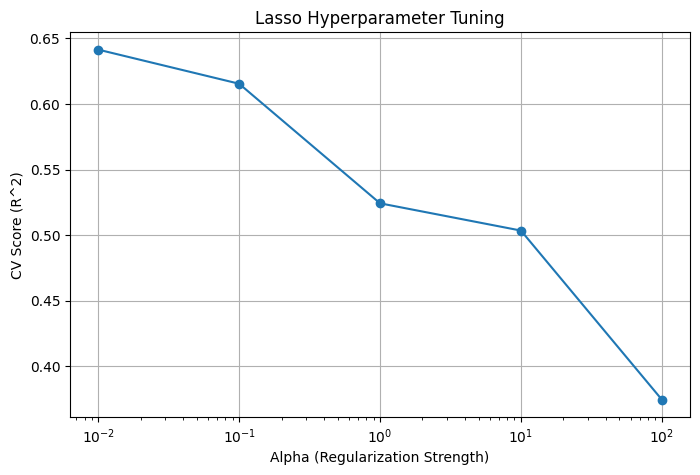

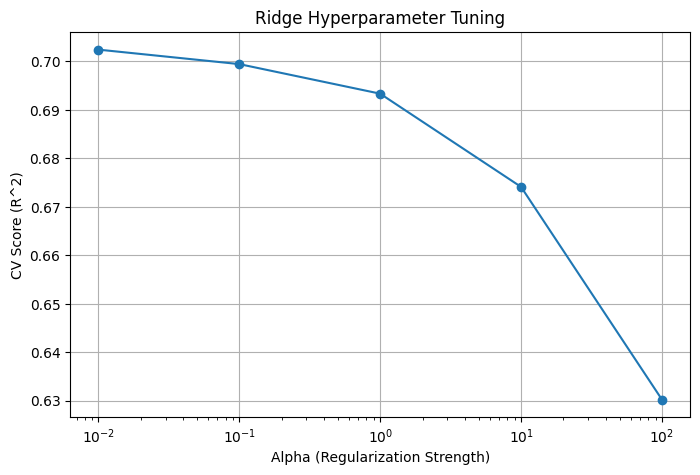

In [63]:
def plot_lasso_ridge(results, title):
    alphas = results['param_alpha'].data
    scores = results['mean_test_score']



    plt.figure(figsize=(8, 5))
    plt.plot(alphas, scores, marker='o')
    plt.xscale('log')
    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('CV Score (R^2)')
    plt.title(title)
    plt.grid()
    plt.show()

# Plot for Lasso
plot_lasso_ridge(lasso_search.cv_results_, "Lasso Hyperparameter Tuning")

# Plot for Ridge
plot_lasso_ridge(ridge_search.cv_results_, "Ridge Hyperparameter Tuning")

KNN

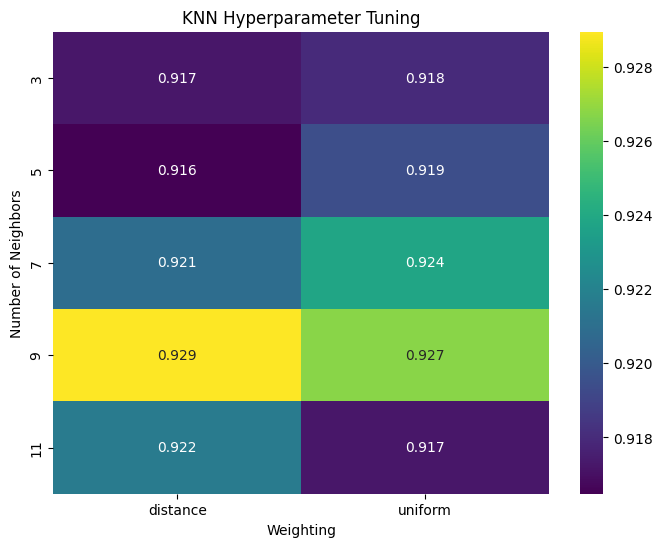

In [65]:
def plot_knn_heatmap(results):


    # Extract grid values
    neighbors = [param['n_neighbors'] for param in results['params']]
    weights = [param['weights'] for param in results['params']]
    scores = results['mean_test_score']

    # Create a DataFrame
    heatmap_data = pd.DataFrame({
        'n_neighbors': neighbors,
        'weights': weights,
        'score': scores
    })

    # Handle duplicate entries by averaging their scores
    heatmap_data = heatmap_data.groupby(['n_neighbors', 'weights'], as_index=False).mean()

    # Create a pivot table for heatmap
    pivot = heatmap_data.pivot(index="n_neighbors", columns="weights", values="score")

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, cmap='viridis', fmt=".3f")  # Use fmt to format the annotations
    plt.title("KNN Hyperparameter Tuning")
    plt.ylabel("Number of Neighbors")
    plt.xlabel("Weighting")
    plt.show()

# Call the function
plot_knn_heatmap(knn_search.cv_results_)

SVC

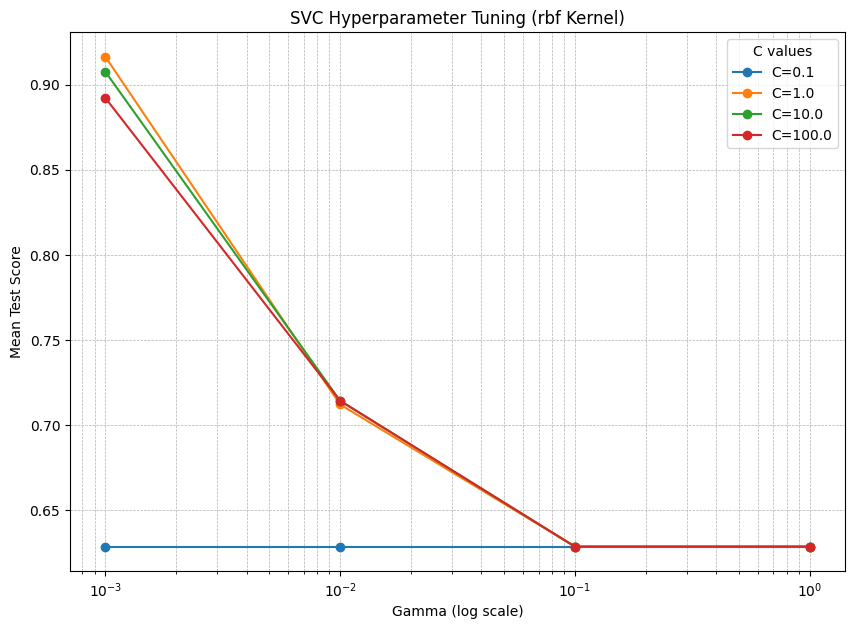

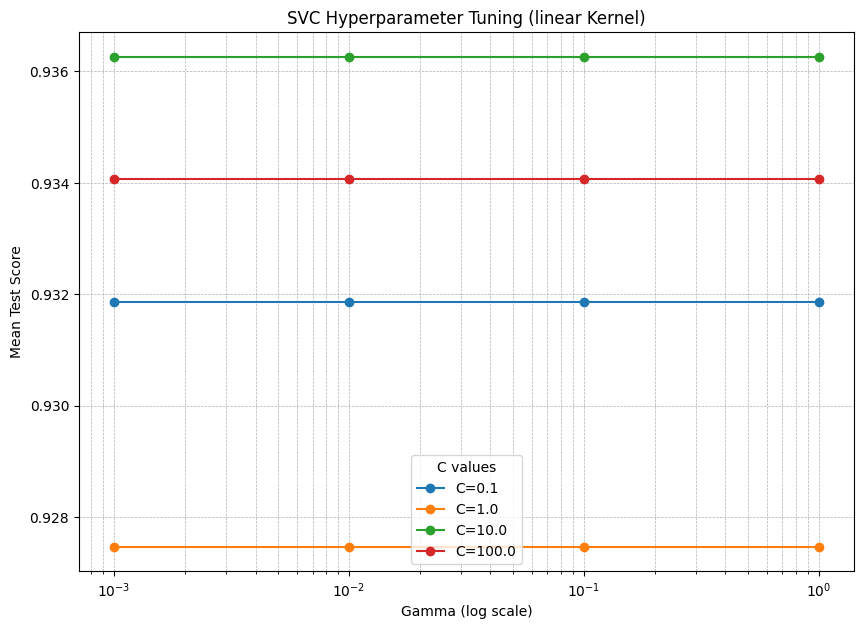

In [72]:
def plot_svc_results(results, kernel):
    # Filter results for the specified kernel
    svc_results = results[results['param_kernel'] == kernel]

    # Check if svc_results is empty
    if svc_results.empty:
        print(f"No results found for kernel: {kernel}")
        return

    # Ensure `param_C` and `param_gamma` are positive
    svc_results = svc_results[(svc_results['param_C'] > 0) & (svc_results['param_gamma'] > 0)]

    # Sort values for consistent plotting
    svc_results = svc_results.sort_values(by=['param_C', 'param_gamma'])

    # Group results by `param_C`
    grouped = svc_results.groupby('param_C')

    plt.figure(figsize=(10, 7))

    # Plot mean_test_score for each `param_gamma`
    for param_C, group in grouped:
        plt.plot(
            group['param_gamma'],
            group['mean_test_score'],
            label=f"C={param_C}",
            marker='o'
        )

    # Customize the plot
    plt.title(f"SVC Hyperparameter Tuning ({kernel} Kernel)")
    plt.xlabel("Gamma (log scale)")
    plt.ylabel("Mean Test Score")
    plt.xscale('log')  # Log scale for Gamma
    plt.legend(title="C values")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# Convert SVC search results to a DataFrame
svc_results_df = pd.DataFrame(svc_search.cv_results_)

# Plot results for 'rbf' and 'linear' kernels
plot_svc_results(svc_results_df, 'rbf')
plot_svc_results(svc_results_df, 'linear')


Random Forest

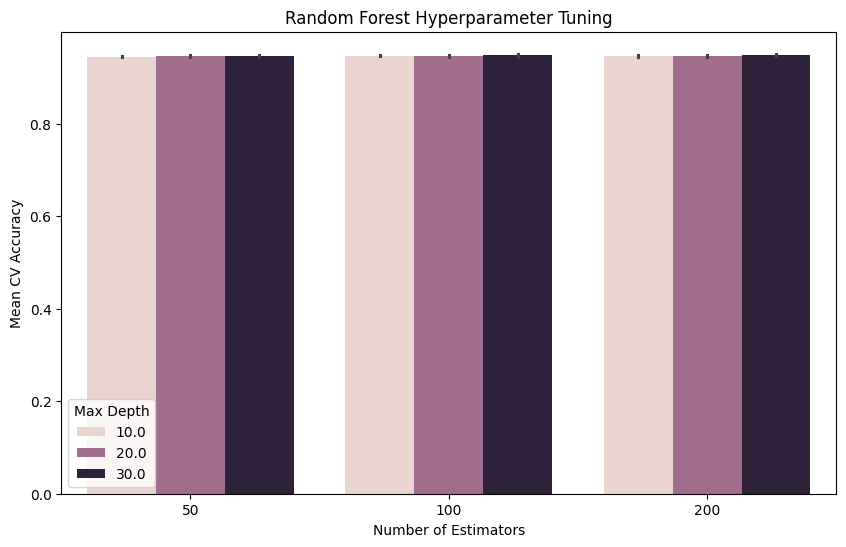

In [67]:
def plot_rf_tuning(results):
    rf_results_df = pd.DataFrame(results.cv_results_)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='param_n_estimators', y='mean_test_score', hue='param_max_depth', data=rf_results_df)
    plt.title("Random Forest Hyperparameter Tuning")
    plt.ylabel("Mean CV Accuracy")
    plt.xlabel("Number of Estimators")
    plt.legend(title="Max Depth")
    plt.show()

plot_rf_tuning(rf_search)

# **Model Evaluation**

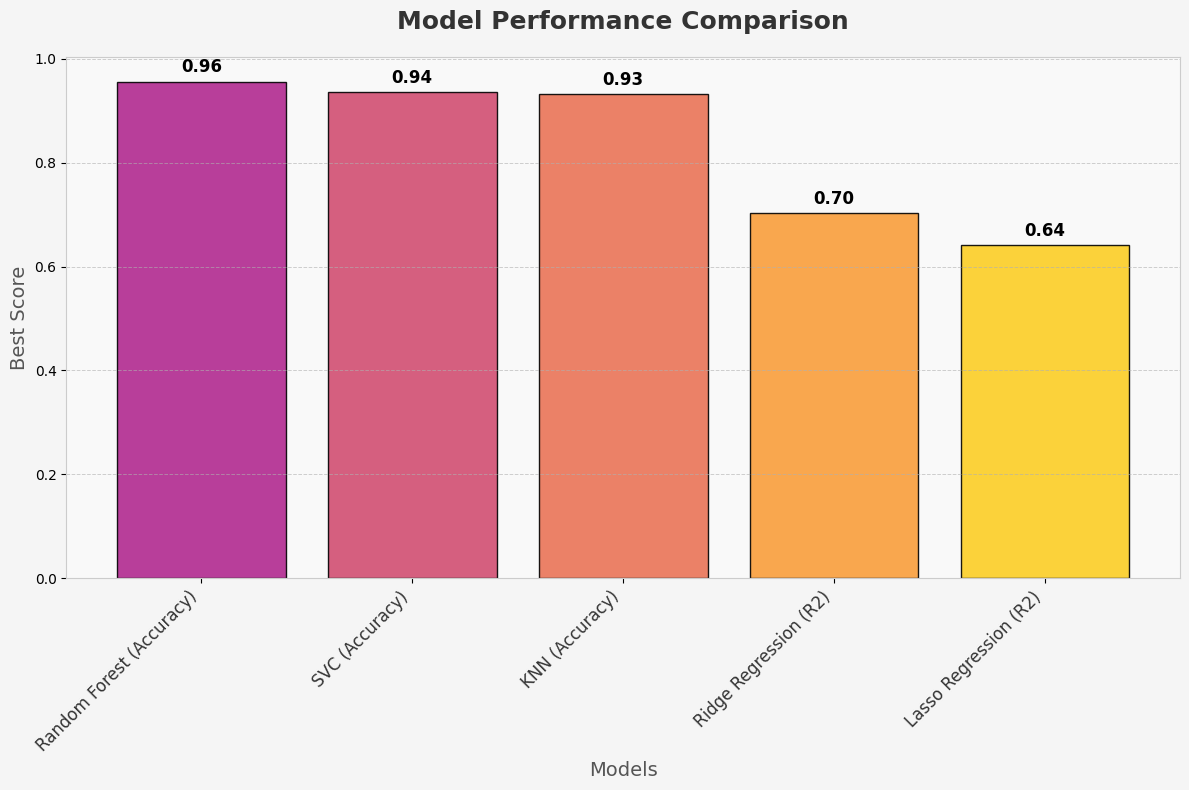

In [78]:

# Collect the best scores from each model
results_dict = {
    "Lasso Regression (R2)": lasso_best_score,
    "Ridge Regression (R2)": ridge_best_score,
    "KNN (Accuracy)": knn_best_score,
    "SVC (Accuracy)": svc_best_score,
    "Random Forest (Accuracy)": rf_best_score
}

# Convert to a DataFrame for better organization
results_df = pd.DataFrame.from_dict(results_dict, orient='index', columns=['Best Score'])

# Sort the results for a clearer visualization
results_df.sort_values(by='Best Score', ascending=False, inplace=True)

# Prepare for gradient coloring
colors = plt.cm.plasma(np.linspace(0.4, 0.9, len(results_df)))

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(results_df.index, results_df['Best Score'], color=colors, edgecolor='black', alpha=0.9)

# Add annotations for the scores
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=12, color='black', weight='bold')

# Add titles and labels
ax.set_title("Model Performance Comparison", fontsize=18, weight='bold', color='#333333', pad=20)
ax.set_ylabel("Best Score", fontsize=14, color='#555555')
ax.set_xlabel("Models", fontsize=14, color='#555555')
ax.set_xticks(np.arange(len(results_df.index)))
ax.set_xticklabels(results_df.index, rotation=45, ha='right', fontsize=12, weight='medium', color='#333333')

# Add gridlines for readability
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.6)

# Add a background and spines customization
fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f9f9f9')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

# Show the plot
plt.tight_layout()
plt.show()


Accuracy Before and after tunning

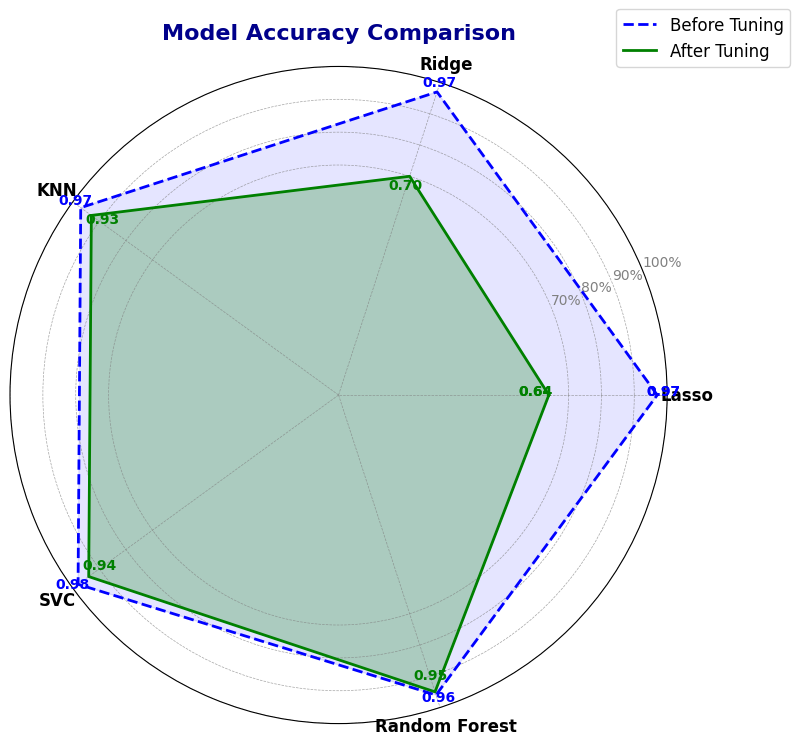

In [90]:
models = ['Lasso', 'Ridge', 'KNN', 'SVC', 'Random Forest']

# Accuracy before and after tuning
accuracy_before = [0.97, 0.97, 0.97, 0.98, 0.96]
accuracy_after = [0.64, 0.70, 0.93, 0.94, 0.95]

# Calculate angles for radar chart
num_models = len(models)
angles = np.linspace(0, 2 * np.pi, num_models, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

# Extend values to close the radar chart
accuracy_before += accuracy_before[:1]
accuracy_after += accuracy_after[:1]

# Radar chart setup
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot before tuning
ax.plot(angles, accuracy_before, label="Before Tuning", color="blue", linestyle="--", linewidth=2)
ax.fill(angles, accuracy_before, color="blue", alpha=0.1)

# Plot after tuning
ax.plot(angles, accuracy_after, label="After Tuning", color="green", linestyle="-", linewidth=2)
ax.fill(angles, accuracy_after, color="green", alpha=0.25)

# Annotate accuracy values
for angle, acc in zip(angles, accuracy_before):
    ax.text(angle, acc + 0.02, f"{acc:.2f}", color="blue", fontsize=10, ha="center", fontweight="bold")

for angle, acc in zip(angles, accuracy_after):
    ax.text(angle, acc - 0.04, f"{acc:.2f}", color="green", fontsize=10, ha="center", fontweight="bold")

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.set_yticks([0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['70%', '80%', '90%', '100%'], color='gray', size=10)

# Add title
ax.set_title("Model Accuracy Comparison", size=16, fontweight='bold', color='darkblue', pad=20)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

# Enhance chart aesthetics
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


# ***Conclusion***

    Negative Impact of Tuning:
        Hyperparameter tuning negatively impacted the performance of all models in this experiment.
        The accuracies of Lasso, Ridge, KNN, SVC, and Random Forest decreased after tuning, with Lasso and Ridge experiencing the most significant drops in accuracy.

    Best Model Pre-Tuning:
        SVC emerged as the best model without tuning, achieving the highest accuracy of 0.98. This indicates that the default hyperparameters of SVC were well-suited for this dataset.

    Post-Tuning Analysis:
        After tuning, the highest accuracy observed was 0.95 for the Random Forest model. While this is still a strong result, it falls short of the pre-tuning performance of SVC.
        For models like Lasso and Ridge, the tuned hyperparameters were not effective in improving accuracy, suggesting a potential mismatch between the chosen parameter ranges and the data characteristics.

    Lessons Learned:
        Default Parameters Can Be Effective: In some cases, default hyperparameters might already be optimal for certain datasets. Over-tuning or selecting unsuitable ranges can lead to degraded performance.
        Model Selection Matters: The superior performance of SVC before tuning highlights the importance of starting with models that align well with the problem's characteristics.
        Validation Process: Tuning must be carefully designed with extensive validation to ensure the changes positively impact the model.

Final Recommendation:

For this project, the SVC model without tuning is the best choice, as it provides the highest accuracy of 0.98. Future efforts should focus on refining the dataset and re-evaluating hyperparameter tuning strategies, potentially using a wider or more targeted parameter search space.